# 03 · Choosing a backbone and training the final model

The preprocessing notebook fixed the input pipeline. This one fixes the model, in two stages. A
grid over four backbones at the two carried frames selects the architecture, and that architecture
is then retrained on the full training set and examined epoch by epoch to settle how long it should
train for. How well the resulting model transfers is measured in notebook 04.

Nothing is trained here, since every figure reads a file that a script in `experiments/` produced,
namely `model_results.csv` for the grid and `checkpoint_eval.csv` for the per-epoch curve.

## Setup

The cell below reads the three results files and defines the display names used by the figures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocular import config

EXP = config.ROOT / "experiments"
models = pd.read_csv(EXP / "results" / "model_results.csv")
curve = pd.read_csv(EXP / "results" / "checkpoint_eval.csv").sort_values("epoch").reset_index(drop=True)

name = {"custom": "custom", "resnet50": "ResNet50", "convnext_tiny": "ConvNeXt-T", "vit_b_16": "ViT-B"}
metrics = [("octdl_recall_DRUSEN", "DRUSEN recall"), ("octdl_macro_f1", "macro-F1")]

## What the grid measures and what it does not

The grid is a screen, not a final measurement. Each backbone is trained on a class-balanced
subsample of three thousand images per class, so that four architectures at two frames fit a fixed
time budget. The scores therefore rank the rows against one another and sit below the full-data
model that follows.

The subsample also treats the candidates unevenly. The custom network starts from random weights and
is data starved at this size, so its score is a lower bound rather than a fair estimate of a network
without pretraining. The pretrained backbones need less data to adapt and are penalised less. Only
the selected architecture is retrained on the full set.

## ConvNeXt-Tiny at the wider frame is the strongest backbone

Four backbones are compared at the square frame and at the one and a half to one frame, under the
same cropped, curvature-corrected and squished pipeline. The ranking criterion is again drusen recall
on the unseen OCTDL set, with macro-F1 second. **Drusen remains the hardest class and the only one
away from the ceiling**, so it is where the backbones actually separate. Across the eight rows its
recall spans 37 points, while CNV stays within 11.

ConvNeXt-Tiny at the wider frame leads on every metric, and the gain sits almost entirely in the
drusen class. Against ResNet50 at a matched frame it adds six points of drusen recall at the square
frame and ten at the wider one, while the two stay within a point or two on overall accuracy.

The bottom of the grid changes with the frame. ViT-B is the weakest pretrained backbone at both,
which suits a supervised transformer on a small subsample whose wrapper also resizes the input down
to a square. The custom network is last at the square frame, as its lack of pretraining predicts, but
at the wider frame ViT-B falls below it on both metrics.

In [2]:
frame = models["width"].astype(str) + "x" + models["height"].astype(str)
grid = pd.DataFrame({
    "model": models["model"].map(name),
    "params_M": (models["params"] / 1e6).round(1),
    "frame": frame,
    "octdl_macro_f1": models["octdl_macro_f1"].round(3),
    "octdl_drusen_recall": models["octdl_recall_DRUSEN"].round(3),
    "clinic_acc": models["clinic_acc"].round(3),
})
grid.sort_values(["frame", "octdl_drusen_recall"], ascending=[True, False]).reset_index(drop=True)

,model,params_M,frame,octdl_macro_f1,octdl_drusen_recall,clinic_acc
0,ConvNeXt-T,27.8,256x256,0.913,0.724,0.649
1,ResNet50,23.5,256x256,0.901,0.667,0.649
2,ViT-B,85.8,256x256,0.867,0.604,0.595
3,custom,1.2,256x256,0.785,0.583,0.351
4,ConvNeXt-T,27.8,384x256,0.917,0.766,0.703
5,ResNet50,23.5,384x256,0.891,0.661,0.595
6,custom,1.2,384x256,0.815,0.516,0.405
7,ViT-B,85.8,384x256,0.802,0.391,0.405


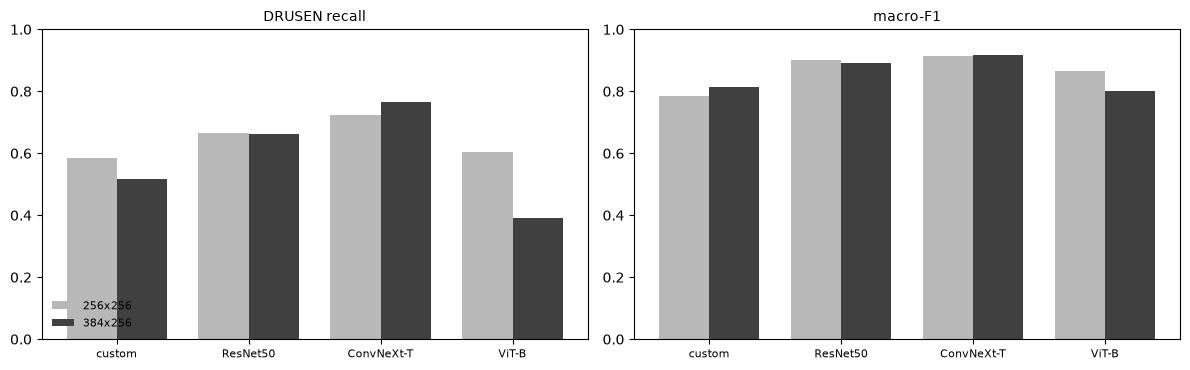

In [3]:
# each backbone at the two frames, drusen recall and macro-F1
model_order = ["custom", "resnet50", "convnext_tiny", "vit_b_16"]
piv = {m: models[models["model"] == m].set_index("width") for m in model_order}
x = np.arange(len(model_order))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (col, label) in zip(axes, metrics):
    ax.bar(x - w / 2, [piv[m].loc[256, col] for m in model_order], w, label="256x256", color="0.72")
    ax.bar(x + w / 2, [piv[m].loc[384, col] for m in model_order], w, label="384x256", color="0.25")
    ax.set_xticks(x)
    ax.set_xticklabels([name[m] for m in model_order], fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 1)
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## The best transfer is at the first epoch

ConvNeXt-Tiny at the wider frame is retrained on the full training set of 73,011 images with class
weights, saving a checkpoint per epoch. Each checkpoint is scored on the Kermany validation split,
the unseen OCTDL set and the clinic scans, which the curve below reads back.

Every measure of transfer peaks at epoch one and never recovers. OCTDL macro-F1 reaches 0.931 and
drusen recall 0.828, and no later epoch comes within seven points of that recall. Clinic accuracy is
also highest at epoch one, matched only by epoch six. The Kermany validation score does the reverse,
sitting at its lowest of 0.948 at epoch one and higher at every later one.

This is source-domain overfitting, in which the model keeps fitting the training distribution while
its features specialise to it and transfer to an unseen device degrades. The validation split is
drawn from that same distribution, so it reads the specialisation as improvement. Here it is not
merely uninformative about transfer but anti-predictive of it, which disqualifies it as a selection
criterion.

> **The first-epoch checkpoint is the model we deliver. It scores best on every measure of transfer,
> and from that epoch onward the model overfits the training set and stops generalising to devices it
> has not seen.**

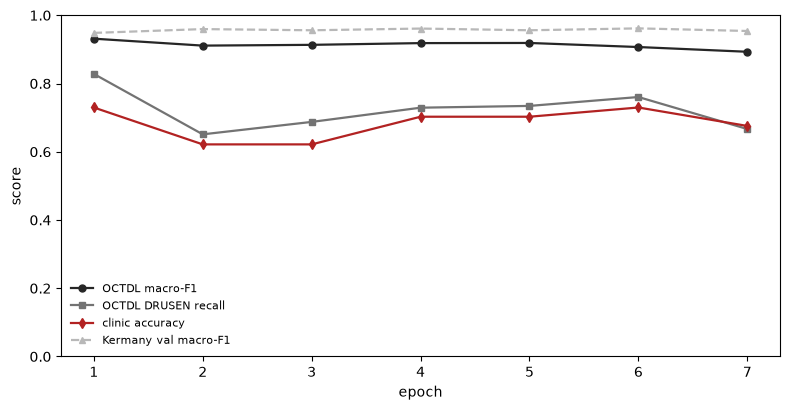

In [4]:
c = curve
styles = [
    ("octdl_macro_f1", "OCTDL macro-F1", "o-", "0.15"),
    ("octdl_recall_DRUSEN", "OCTDL DRUSEN recall", "s-", "0.45"),
    ("clinic_acc", "clinic accuracy", "d-", "#b22222"),
    ("val_macro_f1", "Kermany val macro-F1", "^--", "0.72"),
]
fig, ax = plt.subplots(figsize=(8, 4.2))
for col, label, style, color in styles:
    ax.plot(c["epoch"], c[col], style, label=label, color=color, linewidth=1.6, markersize=5)
ax.set_xlabel("epoch")
ax.set_ylabel("score")
ax.set_xticks(c["epoch"])
ax.set_ylim(0, 1)
ax.legend(fontsize=8, frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## How the training and evaluation are implemented

The model interface is in `ocular/classifier/model.py`, with the training and scoring code in
`train.py` and `eval.py` beside it, so the grid, the final run and every later evaluation share one
implementation.

**Building a candidate.** The function `build_model` loads a torchvision backbone and replaces its
classifier head with a four-way linear layer, which is how ResNet50, ConvNeXt-Tiny and ViT-B enter
the grid from ImageNet features. The custom candidate is `CustomCNN`, a small stack of convolution,
batch-norm and pooling blocks trained from random weights.

**Training.** The function `train` optimises the cross-entropy loss with class weights and saves a
checkpoint after each epoch, which is what makes the per-epoch curve available at all.

**Scoring.** `predict` runs a model over a dataset, `metrics` turns predictions and truths into
accuracy, macro-F1 and per-class recall, and `evaluate` ties the two together. The per-scan clinic
file was written by these rather than computed in the notebook.

## What was run

Two stages wrote the files this notebook reads.

The architecture grid was produced by

    python experiments/run_models.py --per-class 3000 --epochs 5

which trains the four backbones at the two carried frames on the subsample the flag requests, and
appends one row per model and frame to `experiments/results/model_results.csv`. Omitting the flag
trains on the full split and does not reproduce those eight rows.

The final model was trained on the full data with

    python experiments/train_final.py --model convnext_tiny --width 384 --height 256

which saves one checkpoint per epoch. Those checkpoints were scored on the validation split, on OCTDL
and on the clinic by `experiments/eval_checkpoints.py`, which wrote the per-epoch curve to
`experiments/results/checkpoint_eval.csv`.


## Summary

- **ConvNeXt-Tiny at the one and a half to one frame** is strongest on every metric, and its
  advantage over ResNet50 is almost entirely drusen recall.
- **Transfer peaks at the first epoch** and falls after it, while the Kermany validation score rises,
  which makes that score anti-predictive of transfer.
- **The first epoch is therefore the delivered model**, since it is best on every measure of
  transfer, and every later epoch overfits the training set and generalises worse.
- The delivered model reaches a **macro-F1 of 0.931 on the unseen OCTDL set** and is correct on
  **twenty seven of the thirty seven** clinic scans. How that accuracy is distributed, and where it
  breaks, is the subject of notebook 04.

The delivered model is ConvNeXt-Tiny at the wider frame, trained for one epoch on the full training
set under the cropped, curvature-corrected and squished pipeline, saved as
`experiments/convnext_final_e1.pt`.

The following notebook, `04`, measures how that model transfers to the two scanners it has never
seen.